# UNSC Fashion-MNIST — Project Report Notebook

This notebook summarizes the **FastAPI + PyTorch (MPS)** proof-of-concept implementation of **Machine Unlearning via Null Space Calibration (UNSC)** on **Fashion-MNIST**.

It is designed to be run *after* you have already executed the API flow (training + unlearning + baselines). It loads the **saved models** and **saved results** so you can reproduce the final comparison without recomputing everything.

## What this notebook does

- Explains **UNSC Algorithm 1 and Algorithm 2** as implemented in this repo.
- Loads `outputs/results.json` and per-run `outputs/run_<id>.json` files.
- Loads checkpoints from `saved_models/` and (optionally) re-evaluates them.
- Prints a compact comparison of **Original vs UNSC vs Full Retrain vs Random Label**.


## Quick links

- Paper: `https://www.ijcai.org/proceedings/2024/0040.pdf`
- **Comparison figure:** embedded in the root README under **Results** (file: `docs/report/accuracy_comparison.png`).
- Repo artifacts:
  - `saved_models/`: model checkpoints (`.pt`)
  - `outputs/`: results (`results.json`, `run_*.json`) + UNSC caches (`unsc_subspaces_*.pt`, `projection_*.pt`)
  - `data/`: Fashion-MNIST download cache (gitignored)


## Methodology overview (as implemented)

### Baselines

- **Original**: Train a small CNN $\theta_o$ on the full Fashion-MNIST training set.
- **Full retrain**: Train the same CNN **from scratch** on *retained* data only $D_r$ (forget-class removed). Gold standard.
- **Random label fine-tune**: Copy $\theta_o$ then fine-tune on forgotten samples $D_u$ with random wrong labels (simple baseline).

### UNSC (Algorithms 1 & 2)

We implement the paper’s core mechanism: restrict parameter updates to directions that are **orthogonal to retained-class feature subspaces**.

#### Notation

- **Forget class**: $f$
- **Retained dataset**: $D_r = \{(x,y) : y \neq f\}$
- **Forgotten dataset**: $D_u = \{(x,y) : y = f\}$
- **Projection-enabled layers** (this POC): `conv1`, `conv2`, `fc1`, `fc2`.

For each layer $\ell$, collect the **layer input feature columns** (paper’s conv-as-matmul note):

- For linear layers: input matrix $X_{\ell} \in \mathbb{R}^{d_{\ell} \times N}$
- For conv layers: inputs are converted to **patch columns** using `torch.nn.functional.unfold`, giving $X_{\ell} \in \mathbb{R}^{(Ck_hk_w) \times (N\cdot L)}$

#### Algorithm 1 — layer-wise class subspaces (cached)

For each class $k$ and layer $\ell$:

1. Build $X_{\ell}^{(k)}$ from samples with label $k$.
2. Compute SVD: $X_{\ell}^{(k)} = U\Sigma V^\top$
3. Choose the smallest rank $r$ such that cumulative spectral energy exceeds $\epsilon$:

$$
\frac{\sum_{i=1}^{r}\sigma_i^2}{\sum_{i=1}^{m}\sigma_i^2} \ge \epsilon
$$

4. Keep an orthonormal basis $U_{\ell}^{(k)} = U_{[:,1:r]}$ (QR-re-orthonormalized).

Then merge retained classes (exclude $f$) to get a retained span basis $Q_{\ell}$ and construct the **null-space projector**:

$$
P_{\ell} = I - Q_{\ell} Q_{\ell}^\top
$$

These are persisted to `outputs/unsc_subspaces_*.pt` (bases) and `outputs/projection_*.pt` (projectors).

#### Algorithm 2 — null-space calibrated unlearning (run)

For each forgotten mini-batch $x \sim D_u$:

1. **Pseudo-label** using the frozen original model $\theta_o$, excluding the forget class:

$$
\tilde{y} = \arg\max_{c \neq f}\; \theta_o(x)_c
$$

2. Compute cross-entropy loss $\mathcal{L}(\theta_u(x), \tilde{y})$ on the student $\theta_u$.
3. Backprop to get gradients $\nabla W_{\ell}$.
4. Project each layer’s gradient with $P_{\ell}$ so the update stays in the retained **null space**.

This yields a model that (a) reduces accuracy on the forgotten class while (b) preserving retained accuracy better than naive updates.

Artifacts are persisted so later analysis (this notebook) does not need to recompute them.


In [30]:
from __future__ import annotations

import json
import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import torch

REPO = Path.cwd()
OUTPUTS = REPO / "outputs"
SAVED = REPO / "saved_models"

print("repo:", REPO)
print("outputs exists:", OUTPUTS.exists(), "->", OUTPUTS)
print("saved_models exists:", SAVED.exists(), "->", SAVED)
print("torch:", torch.__version__)
print("mps available:", torch.backends.mps.is_available())


repo: /Users/aaqibnazir/Documents/uni/x-ai-project
outputs exists: True -> /Users/aaqibnazir/Documents/uni/x-ai-project/outputs
saved_models exists: True -> /Users/aaqibnazir/Documents/uni/x-ai-project/saved_models
torch: 2.11.0
mps available: True


## Load persisted run results

The API writes an **append-only** run log to `outputs/results.json` and a detailed file per run: `outputs/run_<run_id>.json`.


In [31]:
results_path = OUTPUTS / "results.json"
if not results_path.exists():
    raise FileNotFoundError(f"Missing {results_path}. Run the API flow first.")

results = json.loads(results_path.read_text(encoding="utf-8"))
runs: list[dict[str, Any]] = results.get("runs", [])
print("runs in results.json:", len(runs))
runs[:2]


runs in results.json: 4


[{'run_id': '91fd7714d35d',
  'timestamp_utc': '2026-05-01T11:14:53.867119+00:00',
  'method': 'train_original',
  'forget_class': -1,
  'overall_accuracy': 0.9053,
  'retained_accuracy': 0.9053,
  'forgotten_accuracy': 0.9053,
  'runtime_seconds': 48.984833666996565,
  'model_path': '/Users/aaqibnazir/Documents/uni/x-ai-project/saved_models/original_model.pt',
  'extras_summary_keys': ['final_train_hist']},
 {'run_id': '88fa894f37e5',
  'timestamp_utc': '2026-05-01T11:16:41.883148+00:00',
  'method': 'unsc',
  'forget_class': 0,
  'overall_accuracy': 0.7683,
  'retained_accuracy': 0.8535555555555555,
  'forgotten_accuracy': 0.001,
  'runtime_seconds': 5.926531749995775,
  'model_path': '/Users/aaqibnazir/Documents/uni/x-ai-project/saved_models/unlearned_unsc_c0.pt',
  'extras_summary_keys': ['unsc_history']}]

In [32]:
@dataclass(frozen=True)
class RunRow:
    run_id: str
    timestamp_utc: str
    method: str
    forget_class: int
    overall_accuracy: float
    retained_accuracy: float
    forgotten_accuracy: float
    runtime_seconds: float
    model_path: str | None


def _coerce_float(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return float("nan")


def _fmt(x: float, digits: int = 4) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "nan"
    return f"{x:.{digits}f}"


rows = [
    RunRow(
        run_id=str(r.get("run_id")),
        timestamp_utc=str(r.get("timestamp_utc")),
        method=str(r.get("method")),
        forget_class=int(r.get("forget_class", -1)),
        overall_accuracy=_coerce_float(r.get("overall_accuracy")),
        retained_accuracy=_coerce_float(r.get("retained_accuracy")),
        forgotten_accuracy=_coerce_float(r.get("forgotten_accuracy")),
        runtime_seconds=_coerce_float(r.get("runtime_seconds")),
        model_path=(str(r.get("model_path")) if r.get("model_path") else None),
    )
    for r in runs
]

rows


[RunRow(run_id='91fd7714d35d', timestamp_utc='2026-05-01T11:14:53.867119+00:00', method='train_original', forget_class=-1, overall_accuracy=0.9053, retained_accuracy=0.9053, forgotten_accuracy=0.9053, runtime_seconds=48.984833666996565, model_path='/Users/aaqibnazir/Documents/uni/x-ai-project/saved_models/original_model.pt'),
 RunRow(run_id='88fa894f37e5', timestamp_utc='2026-05-01T11:16:41.883148+00:00', method='unsc', forget_class=0, overall_accuracy=0.7683, retained_accuracy=0.8535555555555555, forgotten_accuracy=0.001, runtime_seconds=5.926531749995775, model_path='/Users/aaqibnazir/Documents/uni/x-ai-project/saved_models/unlearned_unsc_c0.pt'),
 RunRow(run_id='f6cd2598d794', timestamp_utc='2026-05-01T11:17:56.640584+00:00', method='full_retrain', forget_class=0, overall_accuracy=0.7862, retained_accuracy=0.8735555555555555, forgotten_accuracy=0.0, runtime_seconds=69.43740145899937, model_path='/Users/aaqibnazir/Documents/uni/x-ai-project/saved_models/retrained_c0.pt'),
 RunRow(run

In [33]:
def print_leaderboard(rows: list[RunRow], *, forget_class: int | None = None) -> None:
    filt = [r for r in rows if (forget_class is None or r.forget_class == forget_class)]
    filt = sorted(filt, key=lambda r: (r.method, r.forget_class, r.timestamp_utc))

    print("method".ljust(16), "forget".rjust(6), "overall".rjust(10), "retained".rjust(10), "forgotten".rjust(10), "runtime(s)".rjust(11))
    print("-" * 70)
    for r in filt:
        print(
            r.method.ljust(16),
            str(r.forget_class).rjust(6),
            _fmt(r.overall_accuracy).rjust(10),
            _fmt(r.retained_accuracy).rjust(10),
            _fmt(r.forgotten_accuracy).rjust(10),
            _fmt(r.runtime_seconds, digits=2).rjust(11),
        )


print_leaderboard(rows)


method           forget    overall   retained  forgotten  runtime(s)
----------------------------------------------------------------------
full_retrain          0     0.7862     0.8736     0.0000       69.44
random_label          0     0.2862     0.3180     0.0000        3.78
train_original       -1     0.9053     0.9053     0.9053       48.98
unsc                  0     0.7683     0.8536     0.0010        5.93


## Load per-run details (histories)

Each run writes a `run_<id>.json` file that includes a `detail` object. For UNSC, this includes per-epoch `loss` and `pseudo_acc`.


In [34]:
def load_run_detail(run_id: str) -> dict[str, Any]:
    path = OUTPUTS / f"run_{run_id}.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing per-run detail file: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


details = {r.run_id: load_run_detail(r.run_id) for r in rows}
list(details.keys())[:3]


['91fd7714d35d', '88fa894f37e5', 'f6cd2598d794']

In [35]:
unsc_runs = [r for r in rows if r.method == "unsc"]
if not unsc_runs:
    print("No UNSC runs found in results.json")
else:
    latest_unsc = sorted(unsc_runs, key=lambda r: r.timestamp_utc)[-1]
    blob = details[latest_unsc.run_id]
    print("latest UNSC run_id:", latest_unsc.run_id)
    print("detail keys:", list((blob.get("detail") or {}).keys()))
    (blob.get("detail") or {}).get("unsc_history")


latest UNSC run_id: 88fa894f37e5
detail keys: ['unsc_history']


## Verify UNSC Algorithm 1 artifacts exist

UNSC Algorithm 1 caches are saved as `unsc_subspaces_<digest>_<hook_sig>.pt` and a companion `.meta.json`. Projectors are dumped as `projection_<digest>_<hook_sig>_c<forget>.pt`.


In [36]:
unsc_cache = sorted(OUTPUTS.glob("unsc_subspaces_*.pt"))
proj_files = sorted(OUTPUTS.glob("projection_*.pt"))

print("Algorithm 1 cache files:", len(unsc_cache))
for p in unsc_cache:
    print(" -", p.name)

print("\nProjector dump files:", len(proj_files))
for p in proj_files:
    print(" -", p.name)


Algorithm 1 cache files: 2
 - unsc_subspaces_161eec11c49d1607.pt
 - unsc_subspaces_161eec11c49d1607_conv19_conv2144_fc11568_fc2128.pt

Projector dump files: 2
 - projection_161eec11c49d1607_c0.pt
 - projection_161eec11c49d1607_conv19_conv2144_fc11568_fc2128_c0.pt


## (Optional) Re-evaluate saved checkpoints

This section reloads checkpoints from `saved_models/` and recomputes overall/retained/forgotten accuracies using the same dataset split logic.

If you previously selected a forget class (e.g., 0), the loaders will create `test_retained` and `test_forgotten` subsets.


In [37]:
from app.data_loader import build_fashion_mnist_loaders
from app.evaluate import evaluate_splits
from app.model import load_checkpoint
from app.utils import pick_device

device = pick_device()
print("device:", device)

# Adjust this if you ran a different forget class
FORGET_CLASS = 0

loaders = build_fashion_mnist_loaders(
    batch_size_train=128,
    batch_size_eval=256,
    seed=42,
    forget_class=FORGET_CLASS,
)

test_full = loaders["test_full"]
test_ret = loaders["test_retained"]
test_forg = loaders["test_forgotten"]

assert test_full is not None
assert test_ret is not None
assert test_forg is not None

ckpts = {
    "original": SAVED / "original_model.pt",
    "unsc": SAVED / f"unlearned_unsc_c{FORGET_CLASS}.pt",
    "full_retrain": SAVED / f"retrained_c{FORGET_CLASS}.pt",
    "random_label": SAVED / f"random_label_c{FORGET_CLASS}.pt",
}

metrics_recomputed = {}
for name, path in ckpts.items():
    if not path.exists():
        print(f"missing checkpoint: {name} -> {path}")
        continue
    m = load_checkpoint(str(path), device).eval()
    ov, rr, fk = evaluate_splits(
        m,
        test_full_loader=test_full,
        test_retained_loader=test_ret,
        test_forgotten_loader=test_forg,
        device=device,
    )
    metrics_recomputed[name] = {"overall": ov, "retained": rr, "forgotten": fk}

metrics_recomputed


device: mps


{'original': {'overall': 0.904,
  'retained': 0.9066666666666666,
  'forgotten': 0.893},
 'unsc': {'overall': 0.7671,
  'retained': 0.8535555555555555,
  'forgotten': 0.001},
 'full_retrain': {'overall': 0.7848,
  'retained': 0.8735555555555555,
  'forgotten': 0.0},
 'random_label': {'overall': 0.2858, 'retained': 0.318, 'forgotten': 0.0}}

In [38]:
print("recomputed metrics (if available):")
for k, v in metrics_recomputed.items():
    print(k.ljust(12), "overall=", _fmt(float(v["overall"])), "retained=", _fmt(float(v["retained"])), "forgotten=", _fmt(float(v["forgotten"])))


recomputed metrics (if available):
original     overall= 0.9040 retained= 0.9067 forgotten= 0.8930
unsc         overall= 0.7671 retained= 0.8536 forgotten= 0.0010
full_retrain overall= 0.7848 retained= 0.8736 forgotten= 0.0000
random_label overall= 0.2858 retained= 0.3180 forgotten= 0.0000


## Optional visualization

If `matplotlib` is available in your environment, this cell plots the per-epoch UNSC unlearning loss and pseudo-label accuracy from the latest UNSC run.


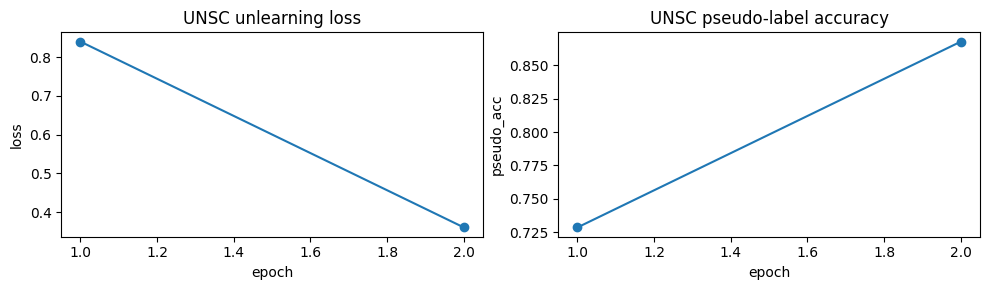

In [39]:
try:
    import matplotlib.pyplot as plt
except Exception as e:  # noqa: BLE001
    plt = None
    print("matplotlib not available:", repr(e))

if plt is not None and unsc_runs:
    hist = (details[latest_unsc.run_id].get("detail") or {}).get("unsc_history")
    if hist:
        xs = hist.get("epoch", [])
        loss = hist.get("loss", [])
        pacc = hist.get("pseudo_acc", [])

        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        ax[0].plot(xs, loss, marker="o")
        ax[0].set_title("UNSC unlearning loss")
        ax[0].set_xlabel("epoch")
        ax[0].set_ylabel("loss")

        ax[1].plot(xs, pacc, marker="o")
        ax[1].set_title("UNSC pseudo-label accuracy")
        ax[1].set_xlabel("epoch")
        ax[1].set_ylabel("pseudo_acc")

        plt.tight_layout()
        plt.show()
    else:
        print("No unsc_history found in latest UNSC run detail.")


## Final results (what to report)

### What each method is doing (one-liners)

- **Original (\(\theta_o\))**: standard supervised training on full data.
- **UNSC (\(\theta_u\))**: pseudo-label forgotten samples and apply **per-layer projected gradients** \(\nabla W_\ell \leftarrow \nabla W_\ell P_\ell\) with \(P_\ell = I - Q_\ell Q_\ell^\top\).
- **Full retrain**: train from scratch on \(D_r\) only.
- **Random label**: fine-tune on \(D_u\) with random wrong labels (no projector).

### The success criterion (how to interpret results)

- **Forgotten accuracy** should become very low.
- **Retained accuracy** should remain reasonably high.
- **Runtime**: UNSC should typically be faster than full retrain.

### Where the evidence lives on disk

- **Metrics**: `outputs/results.json` and `outputs/run_<id>.json`
- **Models**: `saved_models/original_model.pt`, `saved_models/unlearned_unsc_c*.pt`, `saved_models/retrained_c*.pt`, `saved_models/random_label_c*.pt`
- **Algorithm 1 caches + projectors**: `outputs/unsc_subspaces_*.pt` + `outputs/projection_*.pt`

Use the bar plots above plus the curve plots to show both utility (retained/overall) and forgetting effectiveness (forgotten), and include the projector artifacts as proof Algorithm 1 was computed and persisted.


## Plots: final metric comparison (bar charts)

This uses the persisted `outputs/results.json` rows (plus optional recomputed metrics above) to produce bar plots for:

- **Retained / Forgotten / Overall accuracy**
- **Runtime (seconds)**


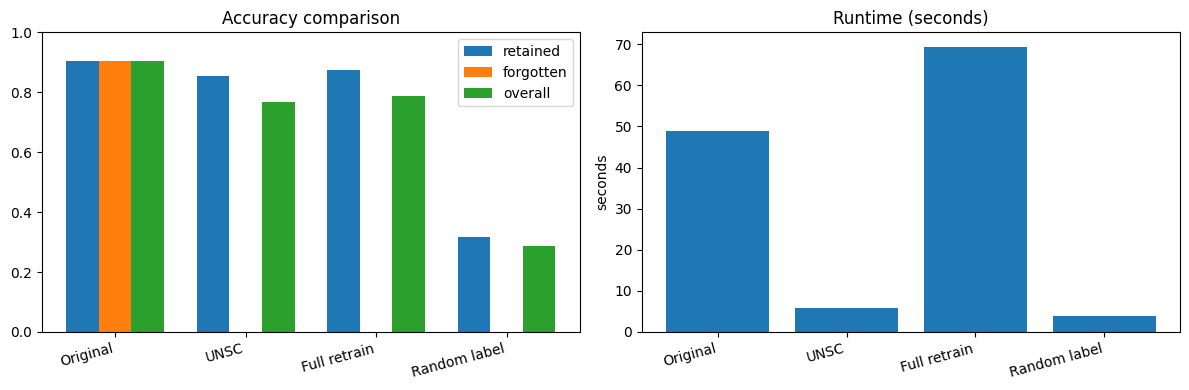

In [40]:
def latest_by_method(rows: list[RunRow], method: str, forget_class: int | None = None) -> RunRow | None:
    cand = [r for r in rows if r.method == method and (forget_class is None or r.forget_class == forget_class)]
    if not cand:
        return None
    return sorted(cand, key=lambda r: r.timestamp_utc)[-1]


def as_display_method(method: str) -> str:
    return {
        "train_original": "Original",
        "warm_cache_original": "Original (cached)",
        "unsc": "UNSC",
        "full_retrain": "Full retrain",
        "random_label": "Random label",
    }.get(method, method)


# Choose the forget class you ran (0 in the saved artifacts currently)
FORGET_CLASS_FOR_PLOTS = 0

methods = ["train_original", "unsc", "full_retrain", "random_label"]
sel = []
for m in methods:
    fc = -1 if m in ("train_original", "warm_cache_original") else FORGET_CLASS_FOR_PLOTS
    row = latest_by_method(rows, m, forget_class=fc)
    if row:
        sel.append(row)

if not sel:
    raise RuntimeError("No matching rows found in outputs/results.json")

# Use matplotlib if present
try:
    import matplotlib.pyplot as plt
except Exception as e:  # noqa: BLE001
    plt = None
    print("matplotlib not available:", repr(e))

if plt is not None:
    labels = [as_display_method(r.method) for r in sel]
    overall = [float(r.overall_accuracy) for r in sel]
    retained = [float(r.retained_accuracy) for r in sel]
    forgotten = [float(r.forgotten_accuracy) for r in sel]
    runtime = [float(r.runtime_seconds) for r in sel]

    x = list(range(len(labels)))
    w = 0.25

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy grouped bars
    ax[0].bar([i - w for i in x], retained, width=w, label="retained")
    ax[0].bar(x, forgotten, width=w, label="forgotten")
    ax[0].bar([i + w for i in x], overall, width=w, label="overall")
    ax[0].set_title("Accuracy comparison")
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(labels, rotation=15, ha="right")
    ax[0].set_ylim(0.0, 1.0)
    ax[0].legend()

    # Runtime bars
    ax[1].bar(x, runtime)
    ax[1].set_title("Runtime (seconds)")
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(labels, rotation=15, ha="right")
    ax[1].set_ylabel("seconds")

    plt.tight_layout()
    plt.show()


## Plots: learning and unlearning curves

We plot the saved curves from the per-run detail files:

- **Original training**: `final_train_hist` (train loss/acc + val acc)
- **UNSC unlearning**: `unsc_history` (loss + pseudo-label accuracy)
- **Full retrain**: `history` (train loss/acc + val acc)
- **Random label**: `random_label_hist` (train loss)

These are pulled from `outputs/run_<id>.json` (no retraining).


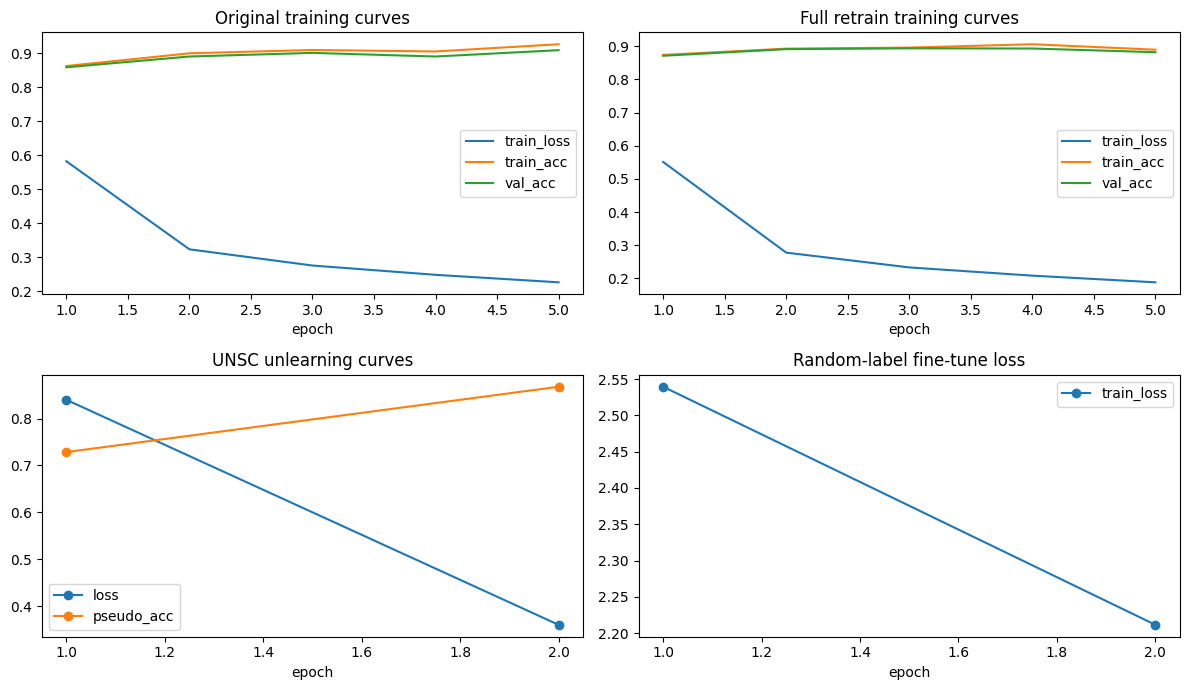

In [41]:
def get_detail_for_method(method: str, forget_class: int) -> dict[str, Any] | None:
    fc = -1 if method in ("train_original", "warm_cache_original") else forget_class
    row = latest_by_method(rows, method, forget_class=fc)
    if row is None:
        return None
    return details.get(row.run_id)


def safe_get(d: dict[str, Any] | None, *keys: str) -> Any:
    cur: Any = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return None
        cur = cur[k]
    return cur


try:
    import matplotlib.pyplot as plt
except Exception as e:  # noqa: BLE001
    plt = None
    print("matplotlib not available:", repr(e))

if plt is not None:
    fc = FORGET_CLASS

    # Original train curves
    d_orig = get_detail_for_method("train_original", fc)
    orig_hist = safe_get(d_orig, "detail", "final_train_hist")

    # Full retrain curves
    d_re = get_detail_for_method("full_retrain", fc)
    retrain_hist = safe_get(d_re, "detail", "history")

    # UNSC unlearning curves
    d_unsc = get_detail_for_method("unsc", fc)
    unsc_hist = safe_get(d_unsc, "detail", "unsc_history")

    # Random label curves
    d_rl = get_detail_for_method("random_label", fc)
    rl_hist = safe_get(d_rl, "detail", "random_label_hist")

    fig, ax = plt.subplots(2, 2, figsize=(12, 7))

    # Original
    if isinstance(orig_hist, dict):
        xs = orig_hist.get("epoch", [])
        ax[0, 0].plot(xs, orig_hist.get("train_loss", []), label="train_loss")
        ax[0, 0].plot(xs, orig_hist.get("train_acc", []), label="train_acc")
        ax[0, 0].plot(xs, orig_hist.get("val_acc", []), label="val_acc")
        ax[0, 0].set_title("Original training curves")
        ax[0, 0].set_xlabel("epoch")
        ax[0, 0].legend()
    else:
        ax[0, 0].set_title("Original training curves (missing)")

    # Full retrain
    if isinstance(retrain_hist, dict):
        xs = retrain_hist.get("epoch", [])
        ax[0, 1].plot(xs, retrain_hist.get("train_loss", []), label="train_loss")
        ax[0, 1].plot(xs, retrain_hist.get("train_acc", []), label="train_acc")
        ax[0, 1].plot(xs, retrain_hist.get("val_acc", []), label="val_acc")
        ax[0, 1].set_title("Full retrain training curves")
        ax[0, 1].set_xlabel("epoch")
        ax[0, 1].legend()
    else:
        ax[0, 1].set_title("Full retrain training curves (missing)")

    # UNSC
    if isinstance(unsc_hist, dict):
        xs = unsc_hist.get("epoch", [])
        ax[1, 0].plot(xs, unsc_hist.get("loss", []), marker="o", label="loss")
        ax[1, 0].plot(xs, unsc_hist.get("pseudo_acc", []), marker="o", label="pseudo_acc")
        ax[1, 0].set_title("UNSC unlearning curves")
        ax[1, 0].set_xlabel("epoch")
        ax[1, 0].legend()
    else:
        ax[1, 0].set_title("UNSC unlearning curves (missing)")

    # Random label
    if isinstance(rl_hist, dict):
        xs = rl_hist.get("epoch", [])
        ax[1, 1].plot(xs, rl_hist.get("train_loss", []), marker="o", label="train_loss")
        ax[1, 1].set_title("Random-label fine-tune loss")
        ax[1, 1].set_xlabel("epoch")
        ax[1, 1].legend()
    else:
        ax[1, 1].set_title("Random-label fine-tune loss (missing)")

    plt.tight_layout()
    plt.show()


## Inference demo: run a saved model on test images

This cell loads a checkpoint from `saved_models/` and runs it on a few Fashion-MNIST test images.

- Set `MODEL_FOR_INFERENCE` to one of: `original`, `unsc`, `full_retrain`, `random_label`.
- If `matplotlib` is available, it will visualize the images with predicted/true labels.


model: unsc
preds: [9, 2, 1, 1, 6, 1]
true : [9, 2, 1, 1, 6, 1]


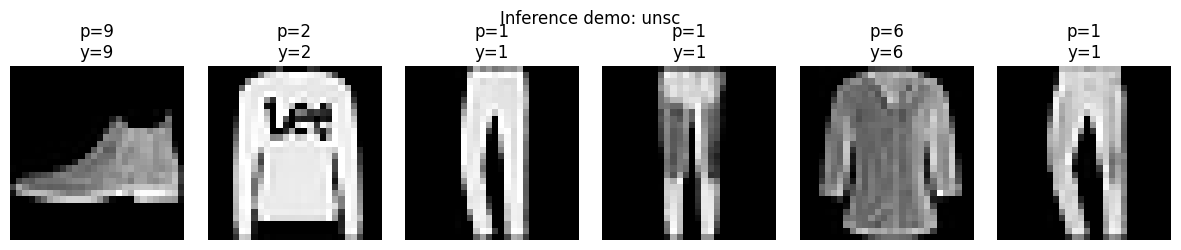

In [42]:
from torchvision import datasets, transforms

# Pick which saved model to demo
MODEL_FOR_INFERENCE = "unsc"  # one of: original, unsc, full_retrain, random_label

ckpt_map = {
    "original": SAVED / "original_model.pt",
    "unsc": SAVED / f"unlearned_unsc_c{FORGET_CLASS}.pt",
    "full_retrain": SAVED / f"retrained_c{FORGET_CLASS}.pt",
    "random_label": SAVED / f"random_label_c{FORGET_CLASS}.pt",
}

ckpt_path = ckpt_map[MODEL_FOR_INFERENCE]
if not ckpt_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

try:
    import matplotlib.pyplot as plt
except Exception as e:  # noqa: BLE001
    plt = None
    print("matplotlib not available:", repr(e))

# Load model
model_inf = load_checkpoint(str(ckpt_path), device).eval()

# Load Fashion-MNIST test set
root = str((REPO / "data").resolve())
test_ds = datasets.FashionMNIST(root=root, train=False, download=True, transform=transforms.ToTensor())

# Take a few samples
idxs = [0, 1, 2, 3, 4, 5]
xs = torch.stack([test_ds[i][0] for i in idxs], dim=0).to(device)
ys = torch.tensor([test_ds[i][1] for i in idxs], dtype=torch.long)

with torch.no_grad():
    logits = model_inf(xs)
    preds = logits.argmax(dim=1).detach().cpu()

print("model:", MODEL_FOR_INFERENCE)
print("preds:", preds.tolist())
print("true :", ys.tolist())

if plt is not None:
    fig, axes = plt.subplots(1, len(idxs), figsize=(12, 2.5))
    for ax, i, p, y in zip(axes, idxs, preds.tolist(), ys.tolist()):
        img = test_ds[i][0].squeeze(0).numpy()
        ax.imshow(img, cmap="gray")
        ax.set_title(f"p={p}\ny={y}")
        ax.axis("off")
    plt.suptitle(f"Inference demo: {MODEL_FOR_INFERENCE}")
    plt.tight_layout()
    plt.show()
